# Description

This notebook demonstrates a real-world use of the `EiaMetadataDownloader` to extract metadata
from the EIA v2 API, explore facet values, construct valid time series URLs, and preview data.
It follows the KaizenFlow notebook style guide and showcases best practices for configuration,
reproducibility, and insight generation.

## Contents
- [Introduction](#introduction)
- [Potential Applications](#potential-applications)
- [Setup](#setup)
  - [Import Required Modules](#import-required-modules)
  - [Set Up API Key](#set-up-api-key)
- [Define Config](#define-config)
- [Initialize Metadata Downloader](#initialize-metadata-downloader)
- [Scenario 1: Metadata Insight](#scenario-1-metadata-insight)
- [Scenario 2: Sample Data Query](#scenario-2-sample-data-query)
- [Wrap-up and Insights](#wrap-up-and-insights)

## Analyzing EIA Time Series Metadata

### Introduction

This notebook demonstrates how to use the `EiaMetadataDownloader` class to analyze and construct valid queries from the U.S. Energy Information Administration (EIA) v2 API. 
It enables data scientists, analysts, and engineers to extract structured metadata, explore available datasets, and build full queryable URLs for accessing time series data.

The EIA v2 API provides metadata about datasets such as electricity consumption, pricing, and production across various regions and time frequencies. 
By programmatically accessing this metadata, you can:
- Discover all frequency-metric combinations available for a dataset.
- Retrieve valid facet (parameter) values like `state`, `sector`, or `provider`.
- Construct full API requests to query time series data.
- Automate ingestion and validation workflows for large-scale energy datasets.

This notebook walks through a real scenario to demonstrate the utility of the metadata downloader.

## Potential Applications

The EIA metadata downloader enables a wide range of analytical and operational tasks by making time series metadata programmatically accessible.

Practical use cases include:
- Creating dashboards that track the availability of new metrics or datasets over time.
- Pre-validating which combinations of frequency, metric, and facets are supported before making data queries.
- Automatically generating full EIA API URLs to feed into a data pipeline or fetcher script.
- Supporting reproducible energy-related research with clear, programmatically obtained dataset references.

## Setup

In this section, we import all required Python libraries and ensure the system is ready to authenticate and run API calls.

We rely on:
- `pandas` for data manipulation.
- `requests` for HTTP communication with the EIA API.### Import Required Modules
- `eia_utils` as part of the project module tree.

### Import Required Modules

In [1]:
%load_ext autoreload
%autoreload 2
import os
import pandas as pd
import logging

import helpers.hdbg as hdbg
import eia_utils as eiu

# Enable logging.
logging.basicConfig(level=logging.INFO)
_LOG = logging.getLogger(__name__)

### Set Up API Key

Store your **EIA API Key** as an environment variable for security. You can do this in your terminal:

```sh
export EIA_API_KEY="your_personal_api_key"
```

Alternatively, you can set it within the notebook:

In [ ]:
# Set your GitHub access token here.
os.environ["EIA_API_KEY"] = ""

# Retrieve it when needed.
api_key = os.getenv("EIA_API_KEY")

# Ensure the token is set correctly.
if not api_key:
    raise ValueError("EIA API key is not set. Please configure it before proceeding.")

## Define Config

This section defines the key parameters that drive the metadata extraction:

- `category`: The root category of interest from the EIA v2 API. Example: `"electricity"`, `"natural-gas"`, `"petroleum"`.
- `version_num`: A version label used to tag output files or datasets.

In [3]:
# Define category and output version.
category = "electricity"
version_num = "1.0"

## Initialize Metadata Downloader

We instantiate the `EiaMetadataDownloader` class using the configuration provided above.

This object encapsulates all the logic needed to:
- Traverse the EIA API tree
- Extract relevant time series metadata
- Retrieve valid facet values for downstream filtering

In [4]:
downloader = eiu.EiaMetadataDownloader(
    category=category,
    api_key=api_key,
    version_num=version_num,
)

## Scenario 1: Constructing a Valid EIA Time Series URL

This scenario walks through the complete process of:
- Selecting a dataset
- Extracting metadata about available frequencies and metrics
- Retrieving all facet values
- Constructing a fully functional EIA API URL using valid parameters

We also preview the data returned by the constructed URL to verify the process end-to-end.

In [5]:
df_metadata, param_entries = downloader.run_metadata_extraction()

### Preview Metadata

In [6]:
df_metadata.head(1)

,url,id,dataset_id,name,description,frequency_id,frequency_alias,frequency_description,frequency_query,frequency_format,facets,data,data_alias,data_units,start_period,end_period,parameter_values_file
0,https://api.eia.gov/v2/electricity/retail-sale...,retail_sales_monthly_revenue,retail_sales,Electricity Sales to Ultimate Customers,Electricity sales to ultimate customer by stat...,monthly,None,One data point for each month.,M,YYYY-MM,"[{'id': 'stateid', 'description': 'State / Cen...",revenue,Revenue from Sales to Ultimate Customers,million dollars,2001-01,2025-02,eia_parameters_v1.0/retail_sales_parameters.csv


### Preview Available Facet Types

In [7]:
# Explore what facet types are available for the time series.
df_metadata[['dataset_id', 'facets']].head(1)

,dataset_id,facets
0,retail_sales,"[{'id': 'stateid', 'description': 'State / Cen..."


### Preview All Facet Values

In [8]:
df_facet = param_entries[0][0]
df_facet.head()

,dataset_id,facet_id,id,name,alias
0,retail_sales,stateid,IN,Indiana,(IN) Indiana
1,retail_sales,stateid,KS,Kansas,(KS) Kansas
2,retail_sales,stateid,MAT,Middle Atlantic,Region: (MAT) Middle Atlantic
3,retail_sales,stateid,CT,Connecticut,(CT) Connecticut
4,retail_sales,stateid,VA,Virginia,(VA) Virginia


### Group and Preview Facet Values by Facet Type

In [9]:
# Show unique facet types and sample values for each.
df_facet.groupby("facet_id").head(1)

,dataset_id,facet_id,id,name,alias
0,retail_sales,stateid,IN,Indiana,(IN) Indiana
62,retail_sales,sectorid,OTH,other,(OTH) other


### Count Time Series per Dataset

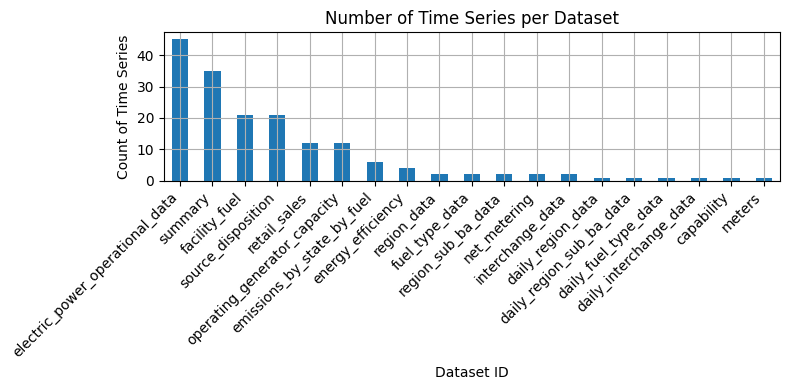

In [10]:
eiu.plot_time_series_count_per_dataset(df_metadata)

### Construct Full URL from One Value per Facet

In [11]:
# Start from base URL.
meta = df_metadata.iloc[0]
base_url = meta["url"].replace("{API_KEY}", api_key)

# Select one value for each facet type.
facet_ids = df_facet["facet_id"].unique()
query_parts = []
for facet_id in facet_ids:
    value = df_facet[df_facet["facet_id"] == facet_id].iloc[0]["id"]
    query_parts.append(f"&{facet_id}={value}")

full_url = base_url + "".join(query_parts)
full_url

'https://api.eia.gov/v2/electricity/retail-sales?api_key=PUdosCqfmw5jkPu3QNyQE1X9MUaRakxllLool9is&frequency=monthly&data[0]=revenue&stateid=IN&sectorid=OTH'

### Sample Data Fetch

In [12]:
response = requests.get(full_url)
json_data = response.json()

NameError: name 'requests' is not defined

In [ ]:
data=json_data.get("response", {})
df_data=pd.DataFrame(data)